# Cycle handoff — train an emulator, replace the forward model

The headline differentiator of `pipekit-train` vs. a backend-only
trainer: **the trained model IS the operator that goes into the
inference loop**. No rewrite, no glue code.

Pattern:

1. An expensive **`ForwardModel`** is what we want to replace.
2. A **`SimulationDataset`** wraps that forward model and yields
   `(state_t, state_{t+dt})` training pairs.
3. A small **neural emulator** trains via `TrainingLoop` to predict
   `state_{t+dt}` from `state_t`.
4. The trained model wraps into **`pipekit_cycle.NeuralForward`** —
   same protocol as the original forward model — and slots straight
   into a **`pipekit_cycle.Cycle`** for fast forecasting.

In [1]:
import equinox as eqx
import jax
import matplotlib.pyplot as plt
import numpy as np
from pipekit import Operator
from pipekit_cycle import Cycle, NeuralForward
from pipekit_train import MSE, SimulationDataset, TrainingLoop
from pipekit_train.adapters.equinox import _EquinoxModelOp

## 1. The expensive forward model

A 2-D damped harmonic oscillator (stand-in for any expensive
physics). In a real workflow this could be a chemistry transport
model, a radiative transfer code, or an ocean GCM.

In [2]:
class DampedOscillator:
    """ForwardModel: x' = x + dt v; v' = v - dt (omega**2 x + gamma v)."""

    dt: float = 0.05
    state_signature = None

    def __init__(self, omega: float = 2.0, gamma: float = 0.1) -> None:
        self.omega = omega
        self.gamma = gamma

    def step(self, state, dt):
        x, v = state[0], state[1]
        return np.stack([x + dt * v, v - dt * (self.omega**2 * x + self.gamma * v)])


expensive = DampedOscillator()

## 2. SimulationDataset — the bridge from forward model to training

`SimulationDataset` yields `(state_t, state_{t+dt})` pairs. The
prior samples initial states; `n_samples` controls the training
set size. Splits (`train`/`val`/`test`) are deterministic via
per-sample seeds.

In [3]:
class GaussianPrior(Operator):
    def __init__(self, scale: float = 1.0) -> None:
        self.scale = scale

    def _apply(self, seed=None):
        rng = np.random.default_rng(seed)
        return rng.standard_normal(2).astype(np.float32) * self.scale

    def __call__(self, *, seed=None):
        return self._apply(seed=seed)


train_ds = SimulationDataset(
    forward_model=expensive,
    prior=GaussianPrior(scale=1.0),
    n_samples=400,
    seed=42,
)

# Peek at one pair.
x0, x1 = train_ds[0]
print(f"sample shape: state_t={x0.shape}, state_t+dt={x1.shape}")
print(f"state_t = {x0}")
print(f"state_t+dt = {x1}")
print(f"dataset content hash: {train_ds.content_hash()[:16]}…")
print(f"# samples in train split: {len(train_ds)}")

sample shape: state_t=(2,), state_t+dt=(2,)
state_t = [ 0.3047171 -1.0399841]
state_t+dt = [ 0.25271788 -1.0957276 ]
dataset content hash: d608772d2f523bbb…
# samples in train split: 320


## 3. Train the emulator

In [4]:
mlp = eqx.nn.MLP(in_size=2, out_size=2, width_size=32, depth=2, key=jax.random.key(0))
emulator_op = _EquinoxModelOp(mlp)

loop = TrainingLoop(
    model_op=emulator_op,
    dataset=train_ds,
    loss=MSE(),
    optimizer_config={"name": "adam", "lr": 1e-2},
    max_steps=400,
    batch_size=16,
    log_every_n_steps=20,
    backend="equinox",
    seed=0,
)

trained_op, artifact = loop.run()
print(
    f"Final MSE after {artifact.backend_info['final_step']} steps: "
    f"{artifact.backend_info['final_metrics']['mse']:.6e}"
)

Final MSE after 400 steps: 8.832775e-05


## 4. Drop the trained model into NeuralForward

`NeuralForward(model_op=trained_op, dt=expensive.dt)` satisfies the
`pipekit_cycle.ForwardModel` Protocol structurally — same `step` /
`dt` interface as the original. Anything that accepts a
`ForwardModel` (including `DACycle`, `EnsembleCycle`, …) now
accepts the emulator.

In [5]:
emulator_forward = NeuralForward(model_op=trained_op, dt=expensive.dt)
print(f"emulator_forward.dt = {emulator_forward.dt}")
print(
    f"emulator_forward satisfies ForwardModel? "
    f"{all(hasattr(emulator_forward, n) for n in ('step', 'dt'))}"
)

emulator_forward.dt = 0.05
emulator_forward satisfies ForwardModel? True


## 5. Compare emulator vs. truth on a rollout

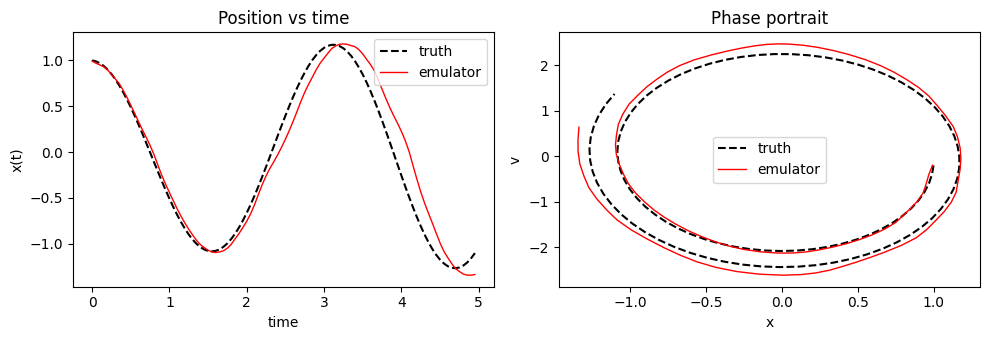

In [6]:
def integrate(forward_model, initial, n_steps):
    """Run a Cycle for n_steps; return the per-step trajectory."""
    cycle = Cycle(step_op=forward_model, n_steps=n_steps, save_history=True)
    cycle(initial, None)
    return np.array([np.asarray(c) for c, _ in cycle.history])


initial = np.array([1.0, 0.0], dtype=np.float32)
n_steps = 100

truth_traj = integrate(expensive, initial, n_steps)
emul_traj = integrate(emulator_forward, initial, n_steps)
t = np.arange(n_steps) * expensive.dt

# Two-panel: position + phase plot.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(t, truth_traj[:, 0], "k--", lw=1.5, label="truth")
axes[0].plot(t, emul_traj[:, 0], "r-", lw=1, label="emulator")
axes[0].set_xlabel("time")
axes[0].set_ylabel("x(t)")
axes[0].set_title("Position vs time")
axes[0].legend()

axes[1].plot(truth_traj[:, 0], truth_traj[:, 1], "k--", lw=1.5, label="truth")
axes[1].plot(emul_traj[:, 0], emul_traj[:, 1], "r-", lw=1, label="emulator")
axes[1].set_xlabel("x")
axes[1].set_ylabel("v")
axes[1].set_title("Phase portrait")
axes[1].legend()

fig.tight_layout()
plt.show()

## 6. The artifact ties it together

`TrainingArtifact` records the training pipeline + dataset hash +
trained-model hash. Pin it alongside the `NeuralForward` config and
the whole train→serve chain is reproducible from one JSON file.

In [7]:
print(f"Backend          : {artifact.backend_info['backend']}")
print(f"JAX version      : {artifact.backend_info['jax_version']}")
print(f"Equinox version  : {artifact.backend_info['equinox_version']}")
print(f"Final loss       : {artifact.backend_info['final_metrics']['mse']:.3e}")
print(f"Total seconds    : {artifact.backend_info['total_seconds']:.2f}")

Backend          : equinox
JAX version      : 0.10.1
Equinox version  : 0.13.8
Final loss       : 8.833e-05
Total seconds    : 1.54


### What's next

- For real geophysical workflows, attach a
  `pipekit_experiment.LocalModelRegistry` (or `S3ModelRegistry`)
  via `Checkpoint(every_n_steps=…, registry=…)` so the trained
  model is content-addressed.
- For amortized inference (SBI), supply an
  `obs_op=pipekit_cycle.ObservationOperator(…)` to `SimulationDataset`
  and train an inverse network — same pattern, different head.
- The emulator drops into `pipekit_cycle.DACycle` just as cleanly
  for ML-augmented data assimilation.